<a name="glossary"></a>
# Replicate Experiments

This notebook runs the following experiments on each of the following mutations:

* G339H - [shikha et al.](https://www.frontiersin.org/journals/immunology/articles/10.3389/fimmu.2023.1209513/full)
* R346T - [groenheit et al.](<https://www.thelancet.com/journals/lanepe/article/PIIS2666-7762(22)00260-5/fulltext>)
* K417N - [barton et al.](https://elifesciences.org/articles/70658)
* V445P - [wang et al.](https://pubmed.ncbi.nlm.nih.gov/36580913/)
* L455F - [focosi et al.](https://pmc.ncbi.nlm.nih.gov/articles/PMC10818967/)
* F456L - [focosi et al.](https://pmc.ncbi.nlm.nih.gov/articles/PMC10818967/)
* E484A - [liu et al.](<https://www.cell.com/cell/fulltext/S1931-3128(21)00044-5>)
* S486P - [tamura et al.](https://www.nature.com/articles/s41467-024-45274-3)
* Q493R - [focosi et al.](https://pmc.ncbi.nlm.nih.gov/articles/PMC8462334/)
* P681H - [lista et al.](https://journals.asm.org/doi/full/10.1128/jvi.01250-22)

We run through the following experiments:
1. <u>[Examining predicted difference](#diffs)</u>
    * We look at the predicted fitness difference of CovFit on the wild-type versus the mutated sequence. <b>Conclusion: The produced figure shows that CovFit predicts each of the mutations to be beneficial for fitness across a wide variety of sequence contexts</b>
2. <u>[Applying CovFit-Regressor to residual stream](#diffs_over_layers)</u>
    * In this experiment, for each mutation, we cache the residual stream on the wild-type and mutated sequence. We then pass these vectors into the CovFit-Regressor (skipping the later layers) to obtain a predicted fitness for the wild-type and mutated sequences. We then look at the fitness difference yielded from each layer. <b>Conclusion: The plot of this over each of the graphs shows that the attention block in layer 32 is the critical block when the model is able to distinguish between the wild-type and mutated sequences</b>
3. <u>[QK-circuit analysis](#qk_analysis)</u>
4. <u>[MLP Activation Patching](#act_patch_mlp)</u>
5. <u>[Testing MLP 31 lookup](#mlp31_lookup)</u>
6. <u>[Replicate path patching](#replicate_path_patching)</u>

In [1]:
# Installing dependencies if Colab
try:
    import google.colab
    IN_COLAB = True
except:
    IN_COLAB = False

if IN_COLAB:
    print("In Colab, installing dependencies", flush=True)
    !pip install biopython jaxtyping circuitsvis transformer-lens==3.0.0 torchao==0.17.0 transformers==4.57.5 datasets==4.4.2 kaleido==0.2.1

    print("Mounting Colab")
    from google.colab import drive
    drive.mount('/content/drive')
    %cd drive/MyDrive/mutational-embedding-vectors/notebooks

In Colab, installing dependencies
Mounting Colab
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/mutational-embedding-vectors/notebooks


In [2]:
import argparse
import os
import pickle
import sys
import typing

import pandas as pd
import torch
from Bio import SeqIO
from typing import List, Union, Optional, Callable, Sequence
from transformers import (
    EsmForMaskedLM,
    EsmConfig,
    PretrainedConfig,
    EsmTokenizer,
    DataCollatorForLanguageModeling,
    Trainer
)

from tokenizers import Tokenizer
import torch
import torch.nn.functional as F
from torch import Tensor, nn

from sklearn.linear_model import LinearRegression

import einops
import yaml
import sys
import json
import functools
import os
import shutil

import numpy as np
from huggingface_hub import hf_hub_download
from peft import LoraConfig, get_peft_model
from datasets import Dataset, load_dataset
import math
from tqdm import tqdm

from matplotlib import pyplot as plt

from jaxtyping import Bool, Float, Int
from plotly.subplots import make_subplots
import plotly.express as px
import plotly.graph_objs as go
import plotly.offline as pyo
import plotly.io as pio
from plotly_utils import (
    imshow,
    line,
    bar
)

import circuitsvis as cv
from IPython.display import display, HTML
from IPython import get_ipython
ip = get_ipython()
if not ip.extension_manager.loaded:
    ip.extension_manager.load('autoreload')
    %autoreload 2

In [3]:
sys.path.append("../config")
import experiment_config

In [4]:
import transformer_lens
import transformer_lens.utils as utils
from transformer_lens.hook_points import (
    HookedRootModule,
    HookPoint,
)

# Hooking utilities
from transformer_lens import (
    HookedTransformer,
    HookedTransformerConfig,
    FactoredMatrix,
    ActivationCache,
)

sys.path.append("../scripts")
from compute_node_embeddings import load_sequences, get_protein_sequence
from branches import json_to_tree
import interp_utils

In [5]:
from covfit_stuff.config import Config, ModelConfig
from covfit_stuff.esm_regression import load_model_for_inference, get_model_predictions, EsmForRegression
import tempfile

In [6]:
torch.autograd.grad_mode.set_grad_enabled(False)
torch.set_float32_matmul_precision("medium")
# small thing to turn off annoying wand questions
os.environ["WANDB_DISABLED"] = "true"
CONTEXT_LEN = experiment_config.CONTEXT_LEN
device = experiment_config.device
print(f"device = {device}")

device = cuda


In [7]:
esm_config, _esm_covfit, (hooked_esm_covfit, get_logit_covfit) = interp_utils.setup_and_load_model(experiment_config, "covfit")
del _esm_covfit
torch.cuda.empty_cache()

(covfit) esm_model <All keys matched successfully>
hooked_model:  <All keys matched successfully>
Note: covfit get_logit_hooked takes 2 inputs -- output and tok_id


In [8]:
tokenizer_config = {}
tokenizer_config["vocab_file"] = experiment_config.VOCAB_FILE
tokenizer_config["model_max_length"] = experiment_config.CONTEXT_LEN

with open(experiment_config.SPECIAL_TOK_MAP, "r") as f:
    tokenizer_config = {**tokenizer_config, **(json.load(f))}

with open(tokenizer_config["vocab_file"], "r") as f:
    f_data = f.read().split("\n")
    aa_to_toks_map = {i:f_data[i] for i in range(len(f_data))}
    aa_to_toks_map_rev = {aa_to_toks_map[k]:k for k in aa_to_toks_map.keys()}

tokenizer = EsmTokenizer(**tokenizer_config)
original_task_id_infos = torch.load(experiment_config.TASK_IDS_FILE, map_location=device)

In [9]:
component_name_map = dict()
for l in range(esm_config.num_hidden_layers + 1):
    if l < esm_config.num_hidden_layers:
        component_name_map[l] = f"blocks.{l}.hook_resid_pre"

    # final layer
    elif l == esm_config.num_hidden_layers:
        component_name_map[l] = f"unembed.hook_in"

logit_id = original_task_id_infos["fitness_USA"]
# clean up memory
torch.cuda.empty_cache()

In [10]:
def get_rev_names(id_seq):
    """
    Given seq x in all_uniq_seqs, get the corresponding name(s) of sequences that have the same spike protein
    """
    if type(id_seq) == int:
        id_seq = [id_seq]

    rev_name_dict = {}
    for id_s in id_seq:
        name_idx = np.argwhere(np.array(seq_idxs) == id_seq)[:,0]
        rev_name_dict[id_s] = [seq_names[x] for x in name_idx]
    return rev_name_dict

### Load Data

In [11]:
def tokenizer_for_map(seq, seq_key="input_ids", tokenizer=tokenizer): #Tokenizer and params including special_tokens_mask required for MLM
    return tokenizer(
        seq[seq_key],
        return_tensors="pt",
        return_special_tokens_mask=True,
        truncation=True,
        padding="max_length",
        max_length=300,
    )

In [12]:
# data loading
with open("../config/pathogen_config.yaml", "r") as config_file:
    config = yaml.safe_load(config_file)
pathogens = list(config["pathogens"].keys())
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer,return_tensors='pt',mlm_probability=0.15)

In [13]:
MAX_LEN=1024
pathogen_suffixes = ["africa", "asia", "europe", "north_america", "oceania", "south_america"]
pathogen_name = "sars_cov_2_spike"
protein_coords = config["pathogens"][f"{pathogen_name}_africa"]["protein_coords"]

In [14]:
name_to_clade_dict = dict()
for suff in pathogen_suffixes:
    print(suff)
    with open(f"../data/pathogen/{pathogen_name}_{suff}/auspice.json", "r") as f:
        tree_json = json.load(f)
        test_tree = json_to_tree(tree_json)
        nodes = list(test_tree.find_clades(order="postorder"))
        name_to_clade_dict.update({n.name:n.node_attrs["clade_membership"]["value"] for n in nodes})

africa
asia
europe
north_america
oceania
south_america


In [15]:
"""
all_uniq_seqs - seqs used in training
seq_names - names of ALL sequences
all_seqs - ALL sequences
seq_idxs - map from seq_names to uniq_seqs, i.e. seq_names[i] is for uniq_seqs[seq_idxs[i]]
"""

all_seqs = []
seq_names = []
seq_idxs = []
all_uniq_seqs = []

for suff in pathogen_suffixes:
    fasta_file = f"../data/pathogen/{pathogen_name}_{suff}/alignment.fasta"
    data = load_sequences(fasta_file)
    sequence_names, sequences = list(zip(*list(data.items())))
    sequences = [get_protein_sequence(x, protein_coords) for x in sequences]

    keep_idx = [i for i,x in enumerate(sequences) if len(x.replace("-","")) > (CONTEXT_LEN // 5) * 4]
    sequences = [sequences[i] for i in keep_idx]
    sequence_names = [sequence_names[i] for i in keep_idx]

    uniq_seqs_suff, unique_inv_idx  = np.unique(sequences, return_inverse=True) # For the purpose of eval, I only care about unique sequences

    all_seqs.extend(sequences)
    seq_names.extend(sequence_names)
    seq_idxs.extend(unique_inv_idx + len(all_uniq_seqs))
    all_uniq_seqs.extend(uniq_seqs_suff)

all_uniq_seqs, unique_inv_idx  = np.unique(all_uniq_seqs, return_inverse=True) # For the purpose of eval, I only care about unique sequences
seq_idxs = [unique_inv_idx[idx] for idx in seq_idxs]
all_uniq_seqs = list(all_uniq_seqs)

# identical code to how it's compute_node_embeddings.py
tok_output = tokenizer(all_uniq_seqs, return_tensors="pt", return_special_tokens_mask=True, truncation=True, padding="max_length", max_length=MAX_LEN)
tok_seqs = tok_output.input_ids.to(device)
tok_masks = tok_output.attention_mask.to(device)

print(pathogen_name)
print(f"Number unique sequences: {len(all_uniq_seqs)}")
print(tok_seqs.shape)

sars_cov_2_spike
Number unique sequences: 4615
torch.Size([4615, 1024])


### Looping through muts

In [16]:
corresponding_heads = {
    "G339H": [(31,7), (32,5), (32,8)],
    "R346T": [(31,7), (32,5), (32,8)],
    "K417N": [(31,7), (32,5), (32,8)],
    "V445P": [(31,7), (32,5), (32,8)],
    "L455F": [(31,7), (32,5), (32,8), (32,13)],
    "F456L": [(32,5), (32,8), (32,13)],
    "E484A": [(31,7), (32,5), (32,8)],
    "S486P": [(32,5), (32,8)],
    "Q493R": [(31,7), (32,5), (32,8)],
    "P681H": [(31,7), (32,8)],
}

In [17]:
relevant_mutations = [
    ("G339H", lambda x: x <= "21M"),
    ("R346T", lambda x: "XBB" in x),
    ("K417N", lambda x: True),
    ("V445P", lambda x: x <= "23I"),
    ("L455F", lambda x: True),
    ("F456L", lambda x: x.endswith("(XBB.1.5)")),
    ("E484A", lambda x: x <= "21M"),
    ("S486P", lambda x: "XBB" in x or "JN" in x or "21" in x),
    ("Q493R", lambda x: x <= "21M"),
    ("P681H", lambda x: x <= "23I"),
]

wt_mut_seq_pairs = dict() # key=mutation, contains the clipped-to-80 pairs of (wt, mut, <mask>) seqs
wt_seq_all_pairs = dict() # key=mutation, contains all pairs of (wt, mut, <mask>) seqs

In [18]:
np.random.seed(0)
for mut, seq_selector in relevant_mutations:
    wt_resid = mut[0]
    mut_resid = mut[-1]
    site = int(mut[1:-1])

    uniq_seqs = np.unique([all_uniq_seqs[seq_idxs[i]] for i,n in enumerate(seq_names) if seq_selector(name_to_clade_dict[n])])
    rand_seqs = np.random.permutation(uniq_seqs)

    all_seq_orig_idx = [x for x in rand_seqs if x[site-1] == wt_resid]
    all_seq_new_idx = [x[:site-1] + mut_resid + x[site:] for x in all_seq_orig_idx]
    all_seq_mask_idx = [x[:site-1] + "<mask>" + x[site:] for x in all_seq_orig_idx]

    print(f"Mutation = {wt_resid} {site} {mut_resid}; {all_seq_orig_idx[10][site-1]}, {all_seq_new_idx[10][site-1]}; {len(all_seq_orig_idx)} total seqs (clipped to 80)")

    all_seq_orig_toks = tokenizer(all_seq_orig_idx, return_tensors="pt", return_special_tokens_mask=True, truncation=True, padding="max_length", max_length=MAX_LEN).input_ids.to(device)
    all_seq_new_toks = tokenizer(all_seq_new_idx, return_tensors="pt", return_special_tokens_mask=True, truncation=True, padding="max_length", max_length=MAX_LEN).input_ids.to(device)
    all_seq_mask_toks = tokenizer(all_seq_mask_idx, return_tensors="pt", return_special_tokens_mask=True, truncation=True, padding="max_length", max_length=MAX_LEN).input_ids.to(device)

    wt_mut_seq_pairs[mut] = (all_seq_orig_toks[:80], all_seq_new_toks[:80], all_seq_mask_toks[:80])
    wt_seq_all_pairs[mut] = (all_seq_orig_toks, all_seq_new_toks, all_seq_mask_toks)

    sanity_check = (wt_mut_seq_pairs[mut][0] !=  wt_mut_seq_pairs[mut][1]).sum(dim=0)
    sanity_check_mask = (wt_mut_seq_pairs[mut][0] !=  wt_mut_seq_pairs[mut][2]).sum(dim=0)
    print(torch.arange(all_seq_orig_toks.shape[-1])[sanity_check.to(bool).cpu()].item(), sanity_check[site].item())
    print(torch.arange(all_seq_orig_toks.shape[-1])[sanity_check_mask.to(bool).cpu()].item(), sanity_check_mask[site].item(), "\n")

Mutation = G 339 H; G, H; 2139 total seqs (clipped to 80)
339 80
339 80 

Mutation = R 346 T; R, T; 113 total seqs (clipped to 80)
346 80
346 80 

Mutation = K 417 N; K, N; 2081 total seqs (clipped to 80)
417 80
417 80 

Mutation = V 445 P; V, P; 2938 total seqs (clipped to 80)
445 80
445 80 

Mutation = L 455 F; L, F; 3547 total seqs (clipped to 80)
455 80
455 80 

Mutation = F 456 L; F, L; 267 total seqs (clipped to 80)
456 80
456 80 

Mutation = E 484 A; E, A; 1804 total seqs (clipped to 80)
484 80
484 80 

Mutation = S 486 P; S, P; 86 total seqs (clipped to 80)
486 80
486 80 

Mutation = Q 493 R; Q, R; 2361 total seqs (clipped to 80)
493 80
493 80 

Mutation = P 681 H; P, H; 1131 total seqs (clipped to 80)
681 80
681 80 



<a name="diffs"></a>
## 1. Examining differences
### [Link to glossary](#glossary)

In [ ]:
def get_diffs(
    model,
    seq_orig_toks,
    seq_new_toks,
    get_logit_hooked,
    n_batch=30,
    logit_id=logit_id
):
    assert seq_orig_toks.shape[0] == seq_new_toks.shape[0], "shape mismatch between seq_orig_toks and seq_new_toks!"

    diffs = np.zeros(seq_orig_toks.shape[0])

    for batch_idx in tqdm(range(0,seq_orig_toks.shape[0],n_batch)):
        batch_seq_orig = seq_orig_toks[batch_idx:batch_idx + n_batch]
        batch_seq_new = seq_new_toks[batch_idx:batch_idx + n_batch]

        batch_orig_output = get_logit_hooked(model(batch_seq_orig), logit_id)
        batch_new_output = get_logit_hooked(model(batch_seq_new), logit_id)

        diffs[batch_idx:batch_idx+n_batch] += (batch_new_output - batch_orig_output).cpu().numpy()
        del batch_orig_output
        del batch_new_output
        torch.cuda.empty_cache()

    return diffs

In [ ]:
fitness_incs = []
# for mut, seq_selector in relevant_mutations:
for mut in wt_mut_seq_pairs.keys():
    # seq_orig_toks, seq_new_toks = wt_mut_seq_pairs[mut]
    seq_orig_toks, seq_new_toks, _ = wt_seq_all_pairs[mut]
    wt_resid = mut[0]
    mut_resid = mut[-1]
    site = int(mut[1:-1])

    diffs = get_diffs(hooked_esm_covfit, seq_orig_toks, seq_new_toks, get_logit_covfit, n_batch=80)
    fitness_incs.append(diffs)
    print(f"{mut} Sanity check -- mean diff: {diffs.mean().item()}, min diff: {diffs.min().item()}, max diff: {diffs.max().item()}\n")

100%|██████████| 27/27 [03:11<00:00,  7.09s/it]


G339H Sanity check -- mean diff: 0.03584919713852059, min diff: -0.005218684673309326, max diff: 0.10662378370761871



100%|██████████| 2/2 [00:10<00:00,  5.07s/it]


R346T Sanity check -- mean diff: 0.017761580975709762, min diff: 0.0006085634231567383, max diff: 0.13726584613323212



100%|██████████| 27/27 [03:06<00:00,  6.90s/it]


...

S486P Sanity check -- mean diff: 0.027562889248825783, min diff: 0.015605688095092773, max diff: 0.030904650688171387



100%|██████████| 30/30 [03:31<00:00,  7.04s/it]


Q493R Sanity check -- mean diff: 0.0711473593301361, min diff: -0.05108138918876648, max diff: 0.25287407636642456



100%|██████████| 15/15 [01:41<00:00,  6.75s/it]

P681H Sanity check -- mean diff: 0.028551362817209446, min diff: -0.14860722422599792, max diff: 0.09636850655078888



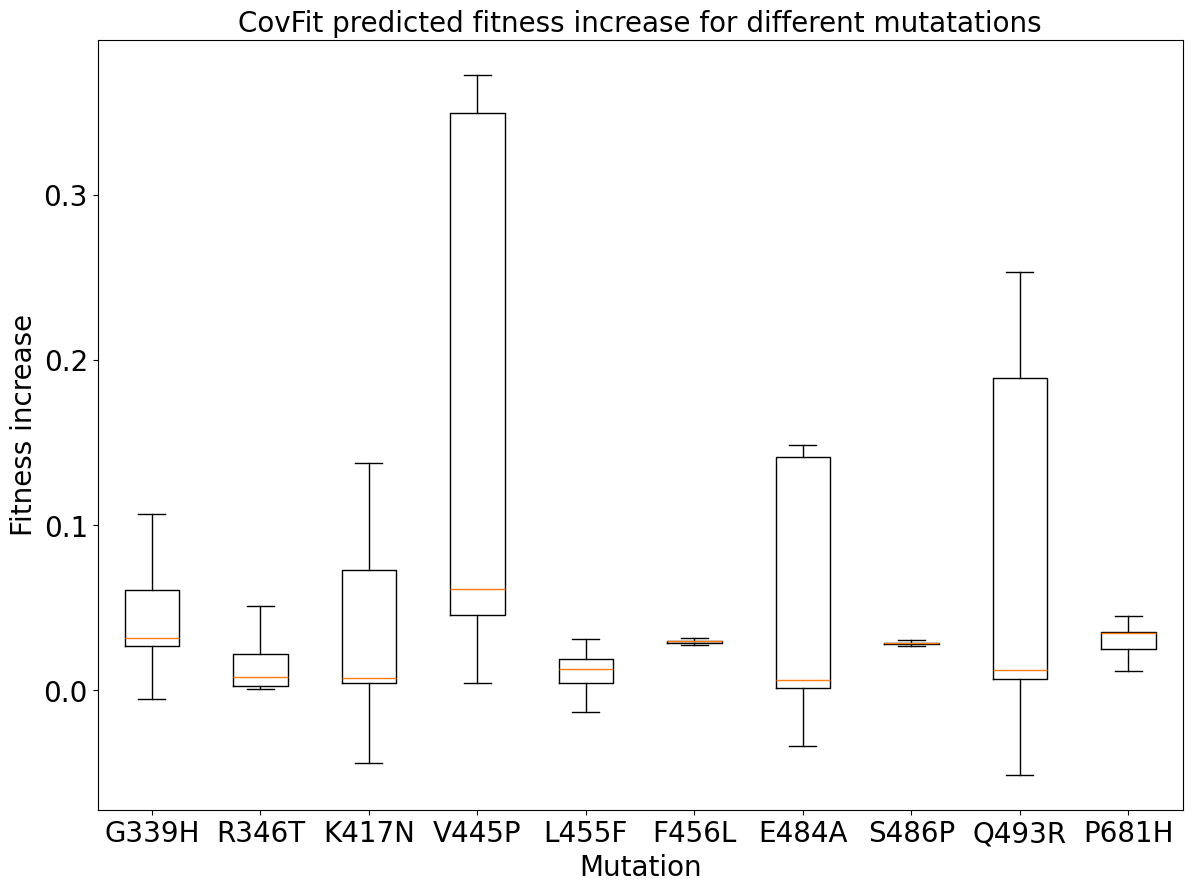

In [ ]:
fig, ax = plt.subplots(1,1,figsize=(14,10))
ax.boxplot(fitness_incs, showfliers=False)
ax.set_title("CovFit predicted fitness increase for different mutatations", fontsize=20)
ax.set_xticks(np.arange(len(fitness_incs)) + 1, [x[0] for x in relevant_mutations], fontsize=20)
ax.tick_params(axis='y', labelsize=20)
plt.ylabel('Fitness increase', fontsize=20)
plt.xlabel('Mutation', fontsize=20)
plt.savefig("../figures/more_mut_diff_plot.png")
plt.show()

<a name=diffs_over_layers></a>
## 2. Plotting fitness difference over layers
### [Link to glossary](#glossary)

In [ ]:
def plot_lines_over_time(
    ax,
    new_toks,
    orig_toks,
    model,
    logit_id=logit_id
):
    resid_component_names = ["blocks.0.hook_resid_pre"]
    for layer in range(hooked_esm.cfg.n_layers):
        resid_mid_name = f"blocks.{layer}.hook_resid_mid"
        resid_post_name = f"blocks.{layer}.hook_resid_post"
        resid_component_names.append(resid_mid_name)
        resid_component_names.append(resid_post_name)

    def patch_resid_direct_to_regressor(toks: Float[Tensor, "n_data d_vocab"]):
        n_data = toks.size(0)
        _, resid_cache = model.run_with_cache(toks, names_filter=resid_component_names)
        torch.cuda.empty_cache()

        logit_results = torch.zeros(n_data, len(resid_component_names)).to(device) #[n_data n_components]
        final_ln = model.ln_final

        # run regressor model on residual stream at each layer (including before attn0 and after final layer norm)
        for i, component in enumerate(resid_component_names):
            resid_component = final_ln(resid_cache[component])
            logit_results[:, i] = get_logit_hooked(resid_component, tok_id=logit_id)
        del _
        del resid_cache
        torch.cuda.empty_cache()

        return logit_results

    high_resid_layer_results = patch_resid_direct_to_regressor(new_toks)
    torch.cuda.empty_cache()
    low_resid_layer_results = patch_resid_direct_to_regressor(orig_toks)
    torch.cuda.empty_cache()

    for j in range(high_resid_layer_results.shape[0]):
        ax.plot(list(range(len(resid_component_names))), high_resid_layer_results[j].cpu().numpy() - low_resid_layer_results[j].cpu().numpy(), color="red", alpha=0.3)
    ax.plot(list(range(len(resid_component_names))), high_resid_layer_results.mean(dim=0).cpu().numpy() - low_resid_layer_results.mean(dim=0).cpu().numpy(), color="black")

    ax.plot(
        [-0.5, len(resid_component_names)+0.5],
        [high_resid_layer_results[:,-1].cpu().mean() - low_resid_layer_results[:,-1].cpu().mean() for _ in range(2)],
        linestyle="dashed",
        color="black"
    )

Mutation = G 339 H;
Mutation = R 346 T;
Mutation = K 417 N;
Mutation = V 445 P;
Mutation = L 455 F;
Mutation = F 456 L;
Mutation = E 484 A;
Mutation = S 486 P;
Mutation = Q 493 R;
Mutation = P 681 H;


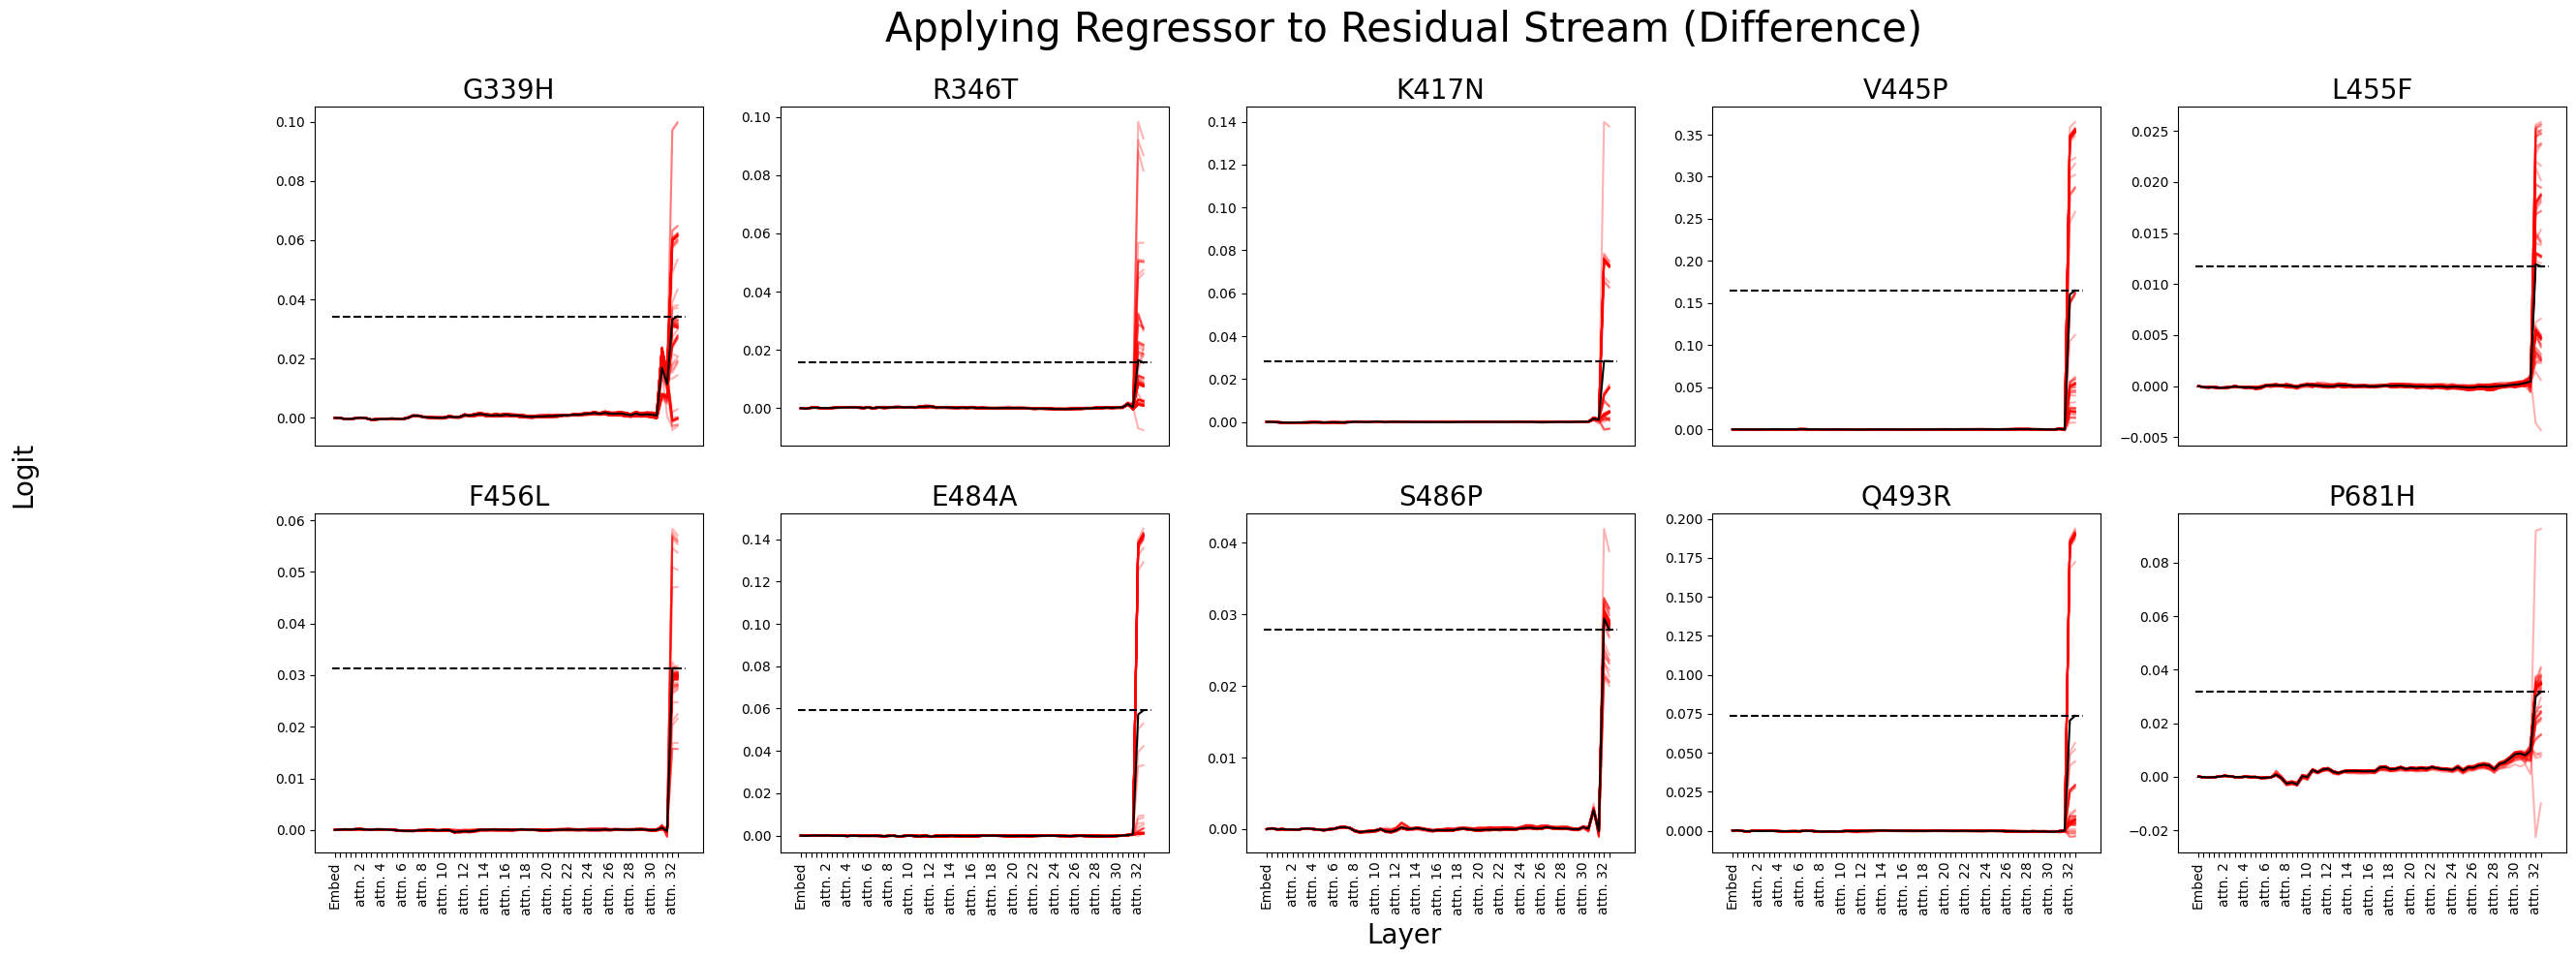

In [ ]:
np.random.seed(0)
# display results
fig, ax = plt.subplots(2,5,figsize=(30,10))
for i, mut in enumerate(wt_mut_seq_pairs.keys()):
    (seq_orig_toks, seq_new_toks, _) = wt_mut_seq_pairs[mut]
    wt_resid = mut[0]
    mut_resid = mut[-1]
    site = int(mut[1:-1])

    print(f"Mutation = {wt_resid} {site} {mut_resid};")

    row = i // 5
    col = i % 5

    plot_lines_over_time(ax[row,col], new_toks=seq_new_toks, orig_toks=seq_orig_toks, model=hooked_esm)
    ax[row,col].set_title(f"{mut}", fontsize=20)
    fig.suptitle("Applying Regressor to Residual Stream (Difference)", fontsize=30)
    if row == 1:
        ax[row,col].set_xticks(
            np.arange(hooked_esm.cfg.n_layers * 2 + 1),
            labels=["Embed", *[f"attn. {idx // 2}" if idx % 4 == 0 and idx != 0 else "" for idx in range(66)]],
            rotation=90,
            fontsize=10
        )
    else:
        ax[row,col].set_xticks([])

fig.supxlabel("\nLayer", fontsize=20)
fig.supylabel("Logit", fontsize=20)
# plt.tight_layout()
plt.savefig("../figures/more_mut_resid_stream.png")
plt.show()

<a name=qk_analysis></a>
## 3. QK-circuit analysis

### [Link to glossary](#glossary)

In [ ]:
# Investigate 484,954 -> 679
# 686 is COMPLETELY CONSERVED REGION

# G339H -- 31.7 for tok 679 (at pos 339)
# R346T -- 32.8, 32.6 at tok 0 (at pos 346), investigate 679 and 339
# K417N -- 31.7 for tok 679 (at pos 417)
# V445P -- 31.7 for tok 679 (at pos 445)
# L455F -- 31.7 for tok 679  (at pos 455)
# F456L -- 32.5, 32.8 at tok 0 (at pos 456)
# E484A -- 31.7 at tok 679, (at pos 484)
# S486P
# Q493R -- 31.7 at tok 679, (at pos 493)
# P681H

In [ ]:
def get_heads_of_interest_orig_mut(mut, layer_head_list, seq_orig_toks, seq_new_toks, model=hooked_esm):
    all_layers = list(set([layer_head[0] for layer_head in layer_head_list]))
    all_layers.sort()

    attn_keys = [utils.get_act_name("pattern",x) for x in all_layers]

    model.reset_hooks(including_permanent=False)
    _, attn_cache_orig = hooked_esm.run_with_cache(seq_orig_toks, names_filter=attn_keys)
    torch.cuda.empty_cache()
    _, attn_cache_mut = hooked_esm.run_with_cache(seq_new_toks, names_filter=attn_keys)
    torch.cuda.empty_cache()

    attn_orig_mean_std = []
    attn_mut_mean_std = []
    for (layer, head) in layer_head_list:
        layer_key = utils.get_act_name("pattern",layer)

        for cache, record in zip([attn_cache_orig, attn_cache_mut], [attn_orig_mean_std, attn_mut_mean_std]):
            attn_val = None
            if layer == 32:
                attn_val = cache[layer_key][:, head, 0, :] # original shape Tensor[batch, n_head, q_seq_len, k_seq_len], only care about cls tok
            else:
                attn_val = cache[layer_key][:, head, :, :]

            # record.append((torch.quantile(attn_val, 0.5, dim=0), torch.quantile(attn_val, 0.25, dim=0), torch.quantile(attn_val, 0.75, dim=0)))
            record.append((attn_val.mean(dim=0), attn_val.std(dim=0)))

    return attn_orig_mean_std, attn_mut_mean_std

In [ ]:
def plot_orig_mut_attn_col(
    orig_attn,
    mut_attn,
    disp_width = 1100,
    disp_height = 500,
    disp_title="",
    disp_col_label=""
):
    """
    orig_attn, mut_attn - Tensor[seq_len]
    """
    disp_tensor = torch.stack([orig_attn, mut_attn], dim=0).cpu()
    fig = imshow(
        disp_tensor.view(-1,32,32),
        facet_col=0,
        x=np.arange(32),
        y=np.arange(32),
        width=disp_width,
        height=disp_height,
        facet_labels=[f"{disp_col_label} clean", f"{disp_col_label} mut"],
        title=disp_title,
        return_fig=True,
    )
    fig.update_traces(customdata=np.arange(1024).reshape(32,32), hovertemplate="%{x}, %{y}<br>Sequence position: 0 <- %{customdata}<br>Attn Prob. %{z}")
    fig.show()
    torch.cuda.empty_cache()
    return fig

In [ ]:
mut_i = relevant_mutations[2][0]
print(mut_i)
(seq_orig_toks, seq_new_toks, _) = wt_mut_seq_pairs[mut_i]
layer_head_list_i = corresponding_heads[mut_i]
attn_orig_mean_std, attn_mut_mean_std = get_heads_of_interest_orig_mut(mut_i, layer_head_list_i, seq_orig_toks, seq_new_toks)

K417N


In [ ]:
# del attn_orig_mean_std
# del attn_mut_mean_std
# torch.cuda.empty_cache()

In [ ]:
for i, (layer, head) in enumerate(layer_head_list_i):
    print(layer, head)
    (attn_orig_mean, attn_orig_std) = attn_orig_mean_std[i]
    (attn_mut_mean, attn_mut_std) = attn_mut_mean_std[i]
    if layer == 32:
        fig = plot_orig_mut_attn_col(
            attn_orig_mean,
            attn_mut_mean,
            disp_title=f"visualizing attn. pattern of <cls> token (1024 -> 32 x 32) for {mut_i} -- L{layer}.H{head}",
            disp_col_label = f"L{layer}.H{head}"
        )
    if layer == 31:
        N = 679
        fig = plot_orig_mut_attn_col(
            attn_orig_mean[N,:],
            attn_mut_mean[N,:],
            disp_title=f"visualizing attn. pattern of {N} token (1024 -> 32 x 32) for {mut_i} -- L{layer}.H{head}",
            disp_col_label = f"L{layer}.H{head}"
        )
    fig.show()
    torch.cuda.empty_cache()

31 7


32 5


32 8


In [ ]:
mut_has_679_k_comp = {
    "G339H": True,
    "R346T": False,
    "K417N": True,
    "V445P": True,
    "L455F": True,
    "F456L": False,
    "E484A": True,
    "S486P": False,
    "Q493R": True,
    "P681H": False,
}

In [ ]:
num_topk = 3

for (mut_i, _) in relevant_mutations:
# for mut_i in [relevant_mutations[2][0]]:
    (seq_orig_toks, seq_new_toks, _) = wt_mut_seq_pairs[mut_i]
    layer_head_list_i = corresponding_heads[mut_i]
    attn_orig_mean_std, attn_mut_mean_std = get_heads_of_interest_orig_mut(mut_i, layer_head_list_i, seq_orig_toks, seq_new_toks)

    wt_resid = mut_i[0]
    mut_resid = mut_i[-1]
    site = int(mut_i[1:-1])

    save_file = f"../figures/{mut_i}_attn_sites.png"

    print(mut_i)
    fig, ax = plt.subplots(1,len(layer_head_list_i),figsize=(4 * len(layer_head_list_i),10))
    for i, (layer, head) in enumerate(layer_head_list_i):
        tok_name = "<cls>"
        print(layer, head)
        (attn_orig_mean, attn_orig_std) = attn_orig_mean_std[i]
        (attn_mut_mean, attn_mut_std) = attn_mut_mean_std[i]

        if layer == 31 and mut_has_679_k_comp[mut_i]:
            tok_name = "679"

            attn_orig_mean = attn_orig_mean[679, :]
            attn_orig_std = attn_orig_std[679, :]

            attn_mut_mean = attn_mut_mean[679, :]
            attn_mut_std = attn_mut_std[679, :]
        elif layer == 31:
            continue

        max_vals, max_tok_idx = attn_mut_mean.topk(k=num_topk,dim=-1)
        ax[i].bar(
            torch.arange(num_topk) - 0.17,
            attn_orig_mean[max_tok_idx].cpu(),
            yerr=attn_orig_std[max_tok_idx].cpu(),
            width=0.34,
            color="green",
            label=f"{wt_resid}{site}"
        )
        ax[i].bar(
            torch.arange(num_topk) + 0.17,
            attn_mut_mean[max_tok_idx].cpu(),
            yerr=attn_mut_std[max_tok_idx].cpu(),
            width=0.34,
            color="orange",
            label=f"{mut_resid}{site}"
        )
        ax[i].set_xticks(torch.arange(num_topk), labels=max_tok_idx.cpu().numpy(), fontsize=15)
        ax[i].set_title(f"L{layer}.H{head}, {tok_name} tok", fontsize=15)
        ax[i].set_ylim([0,1])
        ax[i].set_xlabel("Site", fontsize=20)
        fig.suptitle(f"Top-{num_topk} mean attention sites for\nrelevant heads -- {mut_i}", fontsize=20)

    for a in ax[1:]:
        a.set_yticks([])
    ax[0].set_yticks(np.arange(6) / 5, np.arange(6) / 5, fontsize=15)
    ax[0].set_ylabel("%-20s"%("Attn."), rotation=0, fontsize=20)
    ax[-1].legend(fontsize=15)
    fig.savefig(save_file)
    plt.close()
    print(f"saved to {save_file}")
    del attn_orig_mean_std
    del attn_mut_mean_std
    torch.cuda.empty_cache()

G339H
31 7
32 5
32 8
saved to ../figures/G339H_attn_sites.png
R346T
31 7
32 5
32 8
saved to ../figures/R346T_attn_sites.png
K417N
31 7
32 5
32 8
saved to ../figures/K417N_attn_sites.png
V445P
31 7
32 5
32 8
saved to ../figures/V445P_attn_sites.png
L455F
31 7
32 5
32 8
32 13
saved to ../figures/L455F_attn_sites.png
F456L
32 5
32 8
32 13
saved to ../figures/F456L_attn_sites.png
E484A
31 7
32 5
32 8
saved to ../figures/E484A_attn_sites.png
S486P
32 5
32 8
saved to ../figures/S486P_attn_sites.png
Q493R
31 7
32 5
32 8
saved to ../figures/Q493R_attn_sites.png
P681H
31 7
32 8
saved to ../figures/P681H_attn_sites.png


<a name="act_patch_mlp"></a>
## Activation patching for MLPs
### [Link to glossary](#glossary)
In this experiment, I run through each of the mutations (clipped to 80) and examine how changing the MLP output at each layer affects the final predicted fitness.

Unlike absolute path patching which measures the <b>direct effect</b> of a component on the final predicted fitness, activation path patching measures the <b>total effect</b> of a component.


In [24]:
# Used by many downstream functions
def path_patching_metric(
    logits: Float[Tensor, "batch"],
    corrupted_logit_mean: float,
    clean_logit_mean: float,
):
    """
    Equals 0 when performance is conserved (i.e. high fitness sequences still high fitness)
    Equals -1 when performance is destroyed (high fitness sequence is degraded)
    """

    return ((logits - clean_logit_mean) / (clean_logit_mean - corrupted_logit_mean)).mean().item()

In [ ]:
def patch_to_MLP(
    mlp_vector: Float[Tensor, "batch pos d_model"],
    hook: HookPoint,
    new_vector: Float[Tensor, "batch pos d_model"]
):
    mlp_vector[...] = new_vector
    return mlp_vector

def path_patch_MLP_to_fitness(
    model,
    get_logit_hooked,
    patching_metric,
    new_cache,
    orig_dataset,
    logit_id
):
    MLP_scores = torch.zeros((1, model.cfg.n_layers))

    for layer in tqdm(range(model.cfg.n_layers)):
        model.reset_hooks(including_permanent=False)
        cache_key = utils.get_act_name("mlp_out", layer)

        new_mlp_vector = new_cache[cache_key]
        model.add_hook(
            cache_key,
            functools.partial(
                patch_to_MLP,
                new_vector=new_mlp_vector
            ),
            dir="fwd"
        )

        patched_output = get_logit_hooked(model(orig_dataset), logit_id)
        MLP_scores[:,layer] = patching_metric(patched_output)

    model.reset_hooks(including_permanent=False)
    return MLP_scores

In [ ]:
print("beginning activation patching (MLP)")
mut_MLP_scores = []
for mut, _ in relevant_mutations:
    hooked_esm_covfit.reset_hooks(including_permanent=False)
    print(mut)
    seq_orig_toks, seq_new_toks, _ = wt_mut_seq_pairs[mut]

    corr_toks = seq_orig_toks
    clean_toks = seq_new_toks

    corrupted_logit_mean = get_logit_covfit(hooked_esm_covfit(corr_toks), logit_id).mean().item()
    clean_logit_mean = get_logit_covfit(hooked_esm_covfit(clean_toks), logit_id).mean().item()
    print(corrupted_logit_mean - clean_logit_mean)
    torch.cuda.empty_cache()

    _, new_cache = hooked_esm_covfit.run_with_cache(seq_orig_toks, names_filter=lambda x: "mlp_out" in x)
    mut_MLP_scores.append(path_patch_MLP_to_fitness(
        hooked_esm_covfit,
        get_logit_hooked=get_logit_covfit,
        patching_metric=functools.partial(
            path_patching_metric,
            corrupted_logit_mean=corrupted_logit_mean,
            clean_logit_mean=clean_logit_mean),
        new_cache=new_cache,
        orig_dataset=clean_toks,
        logit_id=logit_id
    ))

    del _
    del new_cache
    torch.cuda.empty_cache()
hooked_esm_covfit.reset_hooks(including_permanent=False)

beginning activation patching (MLP)
G339H
-0.036107391119003296


100%|██████████| 33/33 [01:59<00:00,  3.61s/it]


R346T
-0.0187453031539917


100%|██████████| 33/33 [02:03<00:00,  3.75s/it]


K417N
-0.03711557388305664


...

100%|██████████| 33/33 [02:03<00:00,  3.75s/it]


Q493R
-0.05980220437049866


100%|██████████| 33/33 [02:04<00:00,  3.77s/it]


P681H
-0.02981656789779663


100%|██████████| 33/33 [02:03<00:00,  3.75s/it]


In [ ]:
fig = imshow(
    torch.stack([x.T for x in mut_MLP_scores]),
    labels={"x": "MLP", "y": "Layer", "color": "Change in fitness"},
    title="Activation patching change in fitness (low fitness into high fitness)",
    width=1400,
    height=600,
    facet_labels=[mut for mut, _ in relevant_mutations],
    facet_col=0,
    return_fig=True,
    range_color=(-0.9,0.9)
)
fig.show()
fig.write_image(f"../figures/all_mut_MLP_activation_patch.png", width=1400, height=600, scale=2)

<a name="mlp31_lookup"></a>
## MLP 31 look-up experiment
### [Link to Glossary](#glossary)
What I do in this experiment is patch in counter-factual output to MLP 31 at position 679 and the mutated site and see how that affects the final final predicted fitness

In [ ]:
def patch_MLP_at_idx_hook(
    res_vector: Float[Tensor, "batch pos d_model"],
    hook: HookPoint,
    new_idx_pos: Float[Tensor, "batch d_model"],
    idx
):
    res_vector[:, idx, :] = new_idx_pos[:, idx, :]
    return res_vector

In [ ]:
def counter_factual_MLP31(
    model,
    get_logit_hooked,
    patching_metric,
    orig_dataset,
    counterfactual_dataset,
    ablate_idx,
    n_batch=80,
    logit_id=logit_id
):
    cache_key = utils.get_act_name("mlp_out", 31)
    total_score = 0

    for batch_idx in tqdm(range(0,orig_dataset.shape[0],n_batch)):
        model.reset_hooks()
        batch_seq = orig_dataset[batch_idx:batch_idx+n_batch]
        counterfactual_seq = counterfactual_dataset[batch_idx:batch_idx+n_batch]
        _, counter_factual_cache = model.run_with_cache(counterfactual_seq, names_filter=cache_key)

        # counter_factual_679_seq = new_cache[cache_key][:,679,:]
        counter_factual_idx_seq = counter_factual_cache[cache_key]
        model.add_hook(
            cache_key,
            functools.partial(
                patch_MLP_at_idx_hook,
                new_idx_pos=counter_factual_idx_seq,
                idx=ablate_idx
            ),
            dir="fwd"
        )

        ablated_seq = get_logit_hooked(model(batch_seq), logit_id)
        batch_score = patching_metric(ablated_seq)
        total_score += batch_score * batch_seq.shape[0]
        del _
        del counter_factual_cache
        torch.cuda.empty_cache()
    model.reset_hooks()
    return total_score / orig_dataset.shape[0]

In [ ]:
def get_mean_batched(
    model,
    get_logit_hooked,
    toks,
    logit_id,
    n_batch=80
):
    """
    batched way to get predicted fitness mean of dataset to avoid CUDA OOM errors
    """
    return_val = 0
    for batch_idx in range(0, toks.shape[0], n_batch):
        batch_seq = toks[batch_idx:batch_idx+n_batch]
        return_val += get_logit_hooked(model(batch_seq), logit_id).sum().item()
        torch.cuda.empty_cache()
    return return_val / toks.shape[0]

In [ ]:
MLP31_patch_result_plus679 = []
MLP31_patch_result_679_only = []
MLP31_patch_result_site_only = []
MLP31_mask_result_site_only = []
cache_key = utils.get_act_name("mlp_out", 31)
seq_pairs = wt_seq_all_pairs
# seq_pairs = wt_mut_seq_pairs

batched_mean_func = functools.partial(
    get_mean_batched,
    model=hooked_esm_covfit,
    get_logit_hooked=get_logit_covfit,
    logit_id=logit_id,
    n_batch=100
)

for mut in seq_pairs.keys():
# for mut in ["G339H","K417N","V445P","L455F","E484A","Q493R"]:
    hooked_esm_covfit.reset_hooks()
    wt_aa = mut[1]
    mut_aa = mut[-1]
    site = int(mut[1:-1])
    corr_toks, clean_toks, mask_toks = seq_pairs[mut]

    sanity_check = (corr_toks !=  clean_toks).sum(dim=0)
    sanity_check_mask = (corr_toks !=  mask_toks).sum(dim=0)
    print(torch.arange(corr_toks.shape[-1])[sanity_check.to(bool).cpu()].item(), sanity_check[site].item())
    print(torch.arange(corr_toks.shape[-1])[sanity_check_mask.to(bool).cpu()].item(), sanity_check_mask[site].item())

    corrupted_logit_mean = batched_mean_func(toks=corr_toks)
    torch.cuda.empty_cache()
    clean_logit_mean = batched_mean_func(toks=clean_toks)
    torch.cuda.empty_cache()

    # Create a patching metric that:
    # = 1, when ablating MLP31 at site and 679 destroys performance
    # = 0, when performance is unaffected
    # (Basically -1 * path_patching_metric(), defined a few cells above)
    patching_metric_partial = functools.partial(
        path_patching_metric,
        corrupted_logit_mean=corrupted_logit_mean,
        clean_logit_mean=clean_logit_mean)
    patching_metric = lambda output: -patching_metric_partial(output)

    ablate_MLP31_partial = functools.partial(
        counter_factual_MLP31,
        model=hooked_esm_covfit,
        patching_metric=patching_metric,
        get_logit_hooked=get_logit_covfit,
        orig_dataset=clean_toks
    )
    # (counter-factual) ablate site AND 679
    MLP31_mut_score_plus679 = ablate_MLP31_partial(
        counterfactual_dataset=corr_toks,
        ablate_idx=[site,679]
    )
    # (counter-factual) ablate site AND 679
    MLP31_mut_score_679_only = ablate_MLP31_partial(
        counterfactual_dataset=corr_toks,
        ablate_idx=[679]
    )
    # (counter-factual) ablate site ONLY
    MLP31_mut_score_site_only = ablate_MLP31_partial(
        counterfactual_dataset=corr_toks,
        ablate_idx=[site]
    )
    # (counter-factual) ablate site ONLY
    MLP31_mask_score_site_only = ablate_MLP31_partial(
        counterfactual_dataset=mask_toks,
        ablate_idx=[site]
    )

    MLP31_patch_result_plus679.append(MLP31_mut_score_plus679)
    MLP31_patch_result_679_only.append(MLP31_mut_score_679_only)
    MLP31_patch_result_site_only.append(MLP31_mut_score_site_only)
    MLP31_mask_result_site_only.append(MLP31_mask_score_site_only)
    torch.cuda.empty_cache()

hooked_esm_covfit.reset_hooks()

339 2139
339 2139


100%|██████████| 27/27 [03:10<00:00,  7.04s/it]


346 113
346 113


100%|██████████| 2/2 [00:10<00:00,  5.04s/it]


417 2081
417 2081


...

100%|██████████| 2/2 [00:07<00:00,  3.84s/it]


493 2361
493 2361


100%|██████████| 30/30 [03:29<00:00,  7.00s/it]


681 1131
681 1131


100%|██████████| 15/15 [01:40<00:00,  6.71s/it]


In [ ]:
MLP31_lookup_ablation_dict = pd.DataFrame({
    "mut": list(wt_mut_seq_pairs.keys()),
    "(counter-factual), site + 679 score": MLP31_patch_result_plus679,
    "(counter-factual), 679 score": MLP31_patch_result_679_only,
    "(counter-factual), site score": MLP31_patch_result_site_only,
    "(mask) site score": MLP31_mask_result_site_only})
MLP31_lookup_ablation_dict.to_csv("../figures/MLP31_lookup_results.csv")
MLP31_lookup_ablation_dict

,mut,"(counter-factual), site + 679 score","(counter-factual), 679 score","(counter-factual), site score",(mask) site score
0,G339H,0.705661,0.630228,0.073691,0.073086
1,R346T,0.803676,0.196072,0.603831,0.539117
2,K417N,0.957631,0.953110,0.004328,0.004010
3,V445P,0.798100,0.794448,0.003775,0.002256
4,L455F,0.614097,0.291652,0.320949,0.332207
5,F456L,0.383181,0.000778,0.382401,0.364575
6,E484A,0.911480,0.911702,-0.000248,-0.000114
7,S486P,0.171740,-0.000638,0.172450,0.049080
8,Q493R,0.943363,0.943889,-0.000456,-0.000826
9,P681H,0.853473,0.871228,-0.459193,-0.001471


<a name="replicate_path_patching"></a>
## Replicate Path Patching
### [Link to Glossary](#glossary)

<u>Patching to attn. heads and measuring impact on MLP 31</u>

In [19]:
hooked_esm_covfit.reset_hooks(including_permanent=False)
torch.cuda.empty_cache()

In [ ]:
seq_pairs = wt_mut_seq_pairs
mut_all_abs_patch_32_8_5_13_results = dict()
for mut in seq_pairs.keys():
    print(mut)
    hooked_esm_covfit.reset_hooks()
    wt_aa = mut[1]
    mut_aa = mut[-1]
    site = int(mut[1:-1])
    corr_toks, clean_toks, mask_toks = seq_pairs[mut]

    corrupted_logit_mean = get_logit_covfit(hooked_esm_covfit(corr_toks), logit_id)
    clean_logit_mean = get_logit_covfit(hooked_esm_covfit(clean_toks), logit_id)
    torch.cuda.empty_cache()

    # only need attention info
    _, new_cache = hooked_esm_covfit.run_with_cache(corr_toks, names_filter=lambda x: "hook_z" in x)
    del _
    torch.cuda.empty_cache()
    _, orig_cache = hooked_esm_covfit.run_with_cache(clean_toks, names_filter=lambda x: "hook_z" in x)
    del _
    torch.cuda.empty_cache()

    mut_all_abs_patch_32_8_5_13_results[mut] = interp_utils.abs_path_patch_to_mlp(
        model=hooked_esm_covfit,
        receiver_mlps=[31],
        orig_dataset=clean_toks,
        patching_metric=functools.partial(
            path_patching_metric,
            corrupted_logit_mean=corrupted_logit_mean,
            clean_logit_mean=clean_logit_mean),
        get_logit_hooked=get_logit_covfit,
        new_cache=new_cache,
        orig_cache=orig_cache,
        logit_id=logit_id
    )

    del new_cache
    del orig_cache
    torch.cuda.empty_cache()

G339H


100%|██████████| 640/640 [39:04<00:00,  3.66s/it]


R346T


100%|██████████| 640/640 [39:04<00:00,  3.66s/it]


K417N


100%|██████████| 640/640 [39:04<00:00,  3.66s/it]


V445P


 41%|████▏     | 264/640 [16:07<22:57,  3.66s/it]

<u>Patching to MLP and measuring impact 32.5, 32.8, 32.13</u>

In [ ]:
hooked_esm_covfit.reset_hooks(including_permanent=False)
torch.cuda.empty_cache()

In [ ]:
mlp_names = [f"blocks.{layer}.hook_mlp_out" for layer in range(hooked_esm_covfit.cfg.n_layers)]

In [ ]:
seq_pairs = wt_mut_seq_pairs
mut_all_abs_mlp_patch_32_5_8_13_results = dict()
for mut in seq_pairs.keys():
    print(mut)
    hooked_esm_covfit.reset_hooks()
    wt_aa = mut[1]
    mut_aa = mut[-1]
    site = int(mut[1:-1])
    corr_toks, clean_toks, mask_toks = seq_pairs[mut]

    mut_relevant_heads = [x for x in corresponding_heads[mut] if x[0] == 32]
    print(mut_relevant_heads)

    corrupted_logit_mean = get_logit_covfit(hooked_esm_covfit(corr_toks), logit_id)
    clean_logit_mean = get_logit_covfit(hooked_esm_covfit(clean_toks), logit_id)
    torch.cuda.empty_cache()

    _, orig_cache = hooked_esm_covfit.run_with_cache(clean_toks, names_filter=mlp_names)
    del _
    torch.cuda.empty_cache()
    _, new_cache = hooked_esm_covfit.run_with_cache(corr_toks, names_filter=mlp_names)
    del _
    torch.cuda.empty_cache()

    mut_all_abs_mlp_patch_32_5_8_13_results[mut] = []
    for receiver_input in ["q", "k", "v"]:
        abs_mlp_patch_32_5_8_13 = interp_utils.abs_path_patch_mlp_to_receiver_heads(
            model=hooked_esm_covfit,
            receiver_heads = mut_relevant_heads, # (layer,head)
            receiver_input = receiver_input, #one of {"q", "k", "v"}
            orig_dataset = clean_toks,
            patching_metric = functools.partial(path_patching_metric, corrupted_logit_mean=corrupted_logit_mean, clean_logit_mean=clean_logit_mean),
            get_logit_hooked=get_logit_covfit,
            new_cache = new_cache, # cached attn. mlp
            orig_cache = orig_cache, # cached attn. mlp
            logit_id=logit_id
        )
        torch.cuda.empty_cache()
        mut_all_abs_mlp_patch_32_5_8_13_results[mut].append(abs_mlp_patch_32_5_8_13)

    del new_cache
    del orig_cache
    torch.cuda.empty_cache()

G339H
[(32, 5), (32, 8)]


100%|██████████| 32/32 [01:57<00:00,  3.66s/it]


R346T
[(32, 5), (32, 8)]


100%|██████████| 32/32 [01:57<00:00,  3.66s/it]


K417N
[(32, 5), (32, 8)]


...

100%|██████████| 32/32 [01:57<00:00,  3.66s/it]


Q493R
[(32, 5), (32, 8)]


100%|██████████| 32/32 [01:57<00:00,  3.66s/it]


P681H
[(32, 8)]


100%|██████████| 32/32 [01:56<00:00,  3.65s/it]


In [ ]:
all_abs_mlp_patch_32_5_8_13_results_tensor = []
# torch.empty(10, hooked_esm_covfit.cfg.n_layers, 3)
for i, mut in enumerate(seq_pairs.keys()):
    all_abs_mlp_patch_32_5_8_13_results_tensor.append(torch.stack(mut_all_abs_mlp_patch_32_5_8_13_results[mut], dim=0).T)
    hooked_esm_covfit.reset_hooks(including_permanent=False)

In [ ]:
fig = imshow(
    all_abs_mlp_patch_32_5_8_13_results_tensor,
    labels={"y": "MLP", "x": "Q, K, V", "color": "Change in fitness"},
    title="MLP direct effect on Layer 32 heads -- wild-type into mutated (0 = conserved, -1 = destroyed)",
    facet_col=0,
    facet_labels=[mut for mut, _ in relevant_mutations],
    width=1300,
    height=800,
    range_color=(-1,1),
    return_fig=True
)

fig.write_image("../figures/all_mut_MLP_activation_patch_L32_5_8_13.png")
fig.show()